In [111]:
MODEL_TYPE = 'AdamER_RNN'
MODEL_NAME = 'baseline_rnn_beta0.1'
greedy_or_beam = False

In [112]:
import os

TRAINING_DATA_PATH = f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/training_log'

print(os.path.abspath(TRAINING_DATA_PATH))
print(os.path.exists(TRAINING_DATA_PATH))

/home/yoshi0428/PycharmProjects/comp433_braintotext3/project_files/AdamER_RNN/metrics/baseline_rnn_beta0.1/training_log
True


In [113]:
count = 0
with open(TRAINING_DATA_PATH, errors="ignore") as f:
    for line in f:
        print(line)
        count += 1

print("Total train lines:", count)

2025-11-02 20:20:14,037: Using device: cuda:0

2025-11-02 20:20:14,783: Using torch.compile

2025-11-02 20:20:16,275: Initialized RNN decoding model

2025-11-02 20:20:16,275: OptimizedModule(

  (_orig_mod): GRUDecoder(

    (day_layer_activation): Softsign()

    (day_weights): ParameterList(

        (0): Parameter containing: [torch.float32 of size 512x512]

        (1): Parameter containing: [torch.float32 of size 512x512]

        (2): Parameter containing: [torch.float32 of size 512x512]

        (3): Parameter containing: [torch.float32 of size 512x512]

        (4): Parameter containing: [torch.float32 of size 512x512]

        (5): Parameter containing: [torch.float32 of size 512x512]

        (6): Parameter containing: [torch.float32 of size 512x512]

        (7): Parameter containing: [torch.float32 of size 512x512]

        (8): Parameter containing: [torch.float32 of size 512x512]

        (9): Parameter containing: [torch.float32 of size 512x512]

        (10): Parameter 

In [114]:
import pandas as pd
import re

rows = []
pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): Train batch (?P<batch>\d+): '
    r'loss: (?P<loss>[\d.]+) grad norm: (?P<grad_norm>[\d.]+) '
    r'time: (?P<time>[\d.]+)'
)

with open(TRAINING_DATA_PATH) as f:
    for line in f:
        m = pattern.match(line)
        if m:
            rows.append(m.groupdict())

print(rows[0])

{'timestamp': '2025-11-02 20:20:36,749', 'batch': '0', 'loss': '755.12', 'grad_norm': '299.78', 'time': '3.962'}


In [115]:
df_train = pd.DataFrame(rows)
df_train["batch"] = df_train["batch"].astype(int)
df_train["loss"] = df_train["loss"].astype(float)
df_train["grad_norm"] = df_train["grad_norm"].astype(float)

print(df_train)

                   timestamp   batch    loss  grad_norm   time
0    2025-11-02 20:20:36,749       0  755.12     299.78  3.962
1    2025-11-02 20:22:06,382     200   93.81      14.70  0.210
2    2025-11-02 20:22:55,442     400   74.17      39.42  0.259
3    2025-11-02 20:23:44,213     600   58.98      42.79  0.170
4    2025-11-02 20:24:33,582     800   52.48      60.08  0.256
..                       ...     ...     ...        ...    ...
595  2025-11-03 04:38:11,810  119000    0.00       0.10  0.249
596  2025-11-03 04:39:00,208  119200    0.02       2.14  0.227
597  2025-11-03 04:39:49,888  119400    0.01       0.30  0.216
598  2025-11-03 04:40:38,689  119600    0.01       1.13  0.323
599  2025-11-03 04:41:26,943  119800    0.01       1.68  0.185

[600 rows x 5 columns]


In [116]:
if greedy_or_beam:
    val_pattern = re.compile(
        r'^(?P<timestamp>\S+ \S+): Val batch (?P<batch>\d+): '
        r'PER \(greedy\): (?P<placeholder>[\d.]+) '
        r'PER \(beam\): (?P<per>[\d.]+) '
        r'Cross Entropy Loss \(avg\): (?P<celoss>[\d.]+) '
        r'time: (?P<time>[\d.]+)'
    )
else:
    val_pattern = re.compile(
        r'^(?P<timestamp>\S+ \S+): Val batch (?P<batch>\d+): '
        r'PER \(avg\): (?P<per>[\d.]+) '
        r'CTC Loss \(avg\): (?P<ctcloss>[\d.]+) '
        r'time: (?P<time>[\d.]+)'
    )

vals = []
with open(TRAINING_DATA_PATH) as f:
    for line in f:
        m = val_pattern.match(line)
        if m:
            vals.append(m.groupdict())

print(vals[0])

{'timestamp': '2025-11-02 20:21:15,378', 'batch': '0', 'per': '1.2148', 'ctcloss': '715.3579', 'time': '38.628'}


In [117]:
df_val = pd.DataFrame(vals)
df_val["batch"] = df_val["batch"].astype(int)
df_val["per"] = df_val["per"].astype(float)

if greedy_or_beam:
    df_val["celoss"] = df_val["celoss"].astype(float)
else:
    df_val["ctcloss"] = df_val["ctcloss"].astype(float)

print(df_val)

                  timestamp   batch     per   ctcloss    time
0   2025-11-02 20:21:15,378       0  1.2148  715.3579  38.628
1   2025-11-02 20:29:40,965    2000  0.2235   22.5810  13.821
2   2025-11-02 20:38:08,592    4000  0.1587   17.5449  13.709
3   2025-11-02 20:46:37,487    6000  0.1412   17.9229  13.604
4   2025-11-02 20:55:05,526    8000  0.1322   17.8916  13.599
..                      ...     ...     ...       ...     ...
56  2025-11-03 04:09:12,552  112000  0.1019   22.4106  14.026
57  2025-11-03 04:17:35,682  114000  0.1013   22.3988  18.131
58  2025-11-03 04:25:52,848  116000  0.1009   22.4791  14.142
59  2025-11-03 04:34:09,942  118000  0.1015   22.4540  13.763
60  2025-11-03 04:42:30,978  119999  0.1016   22.4374  14.855

[61 rows x 5 columns]


# Training metrics

### Losses over batches

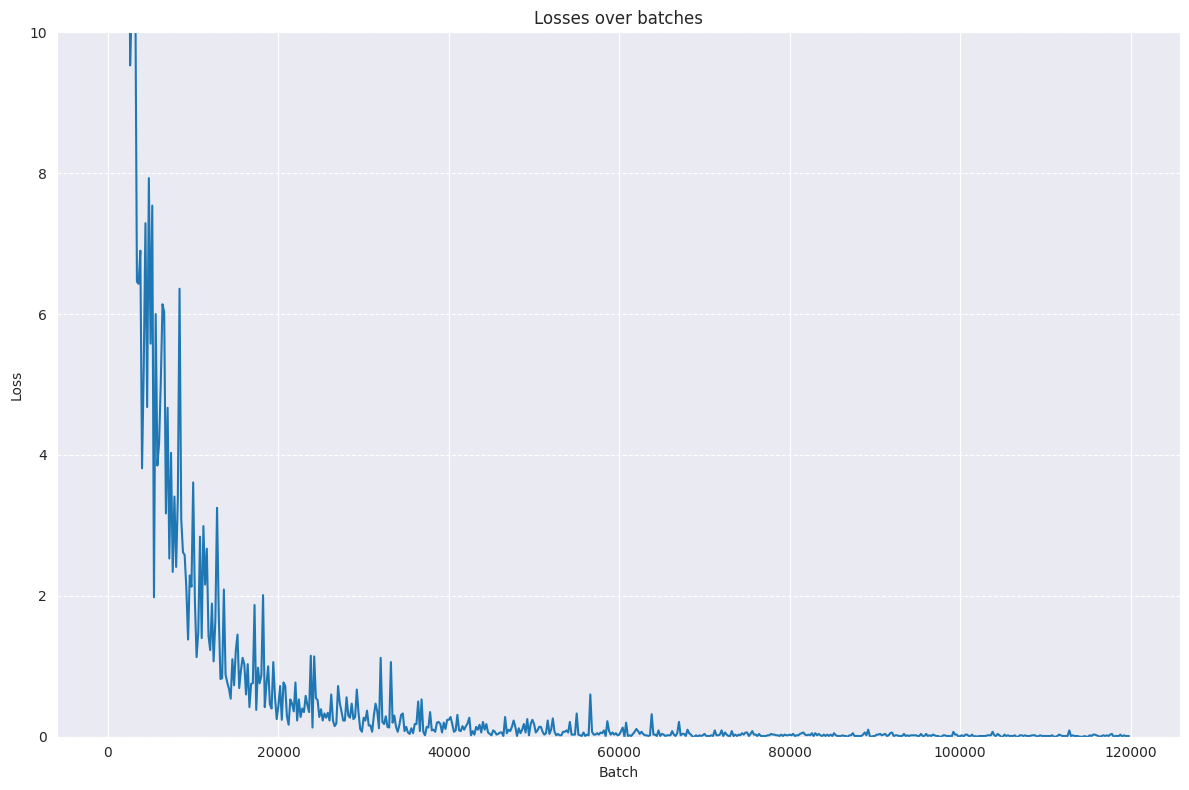

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(df_train['batch'], df_train['loss'])
plt.title('Losses over batches')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(axis='y', linestyle='--')
plt.ylim(0, 10)

plt.tight_layout()
plt.savefig(f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/train_losses.png')
plt.show()

### Grad Norm over batches

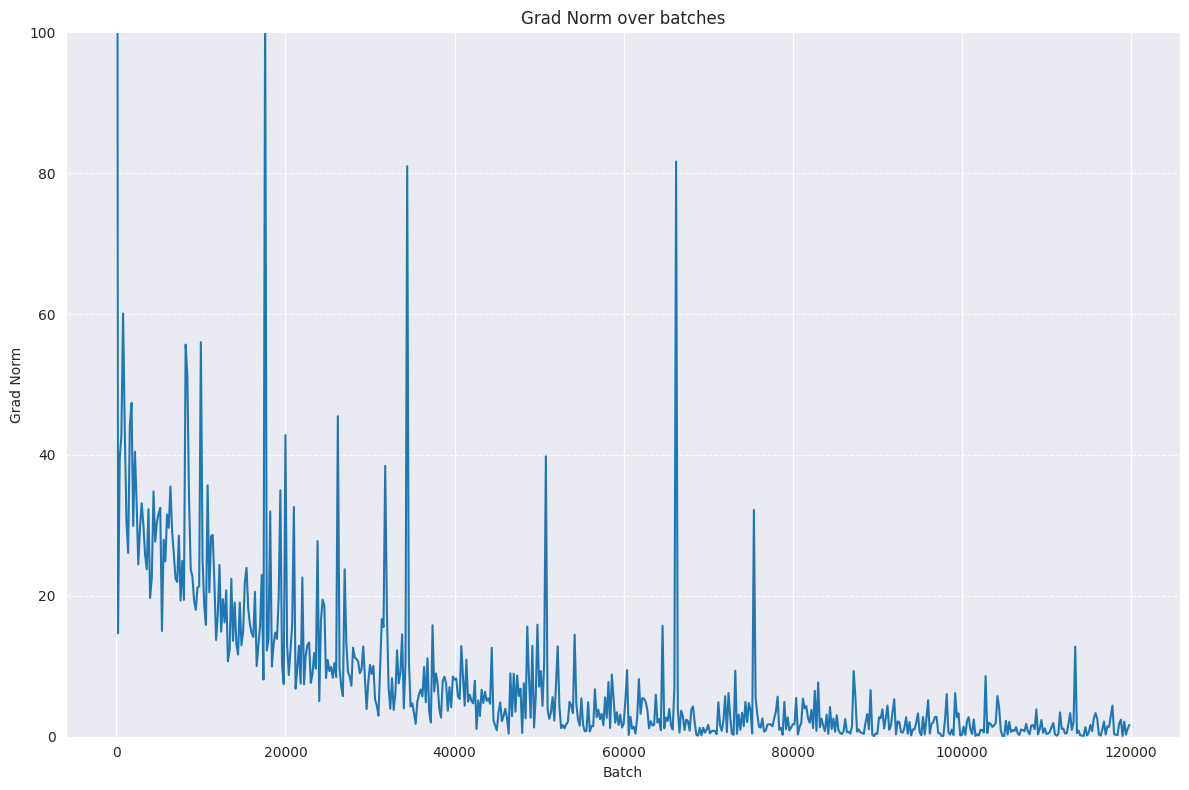

In [119]:
plt.figure(figsize=(12, 8))
plt.plot(df_train['batch'], df_train['grad_norm'])
plt.title('Grad Norm over batches')
plt.xlabel('Batch')
plt.ylabel('Grad Norm')
plt.grid(axis='y', linestyle='--')
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig(f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/grad_norm.png')
plt.show()

# Validation metrics

### PER over batches

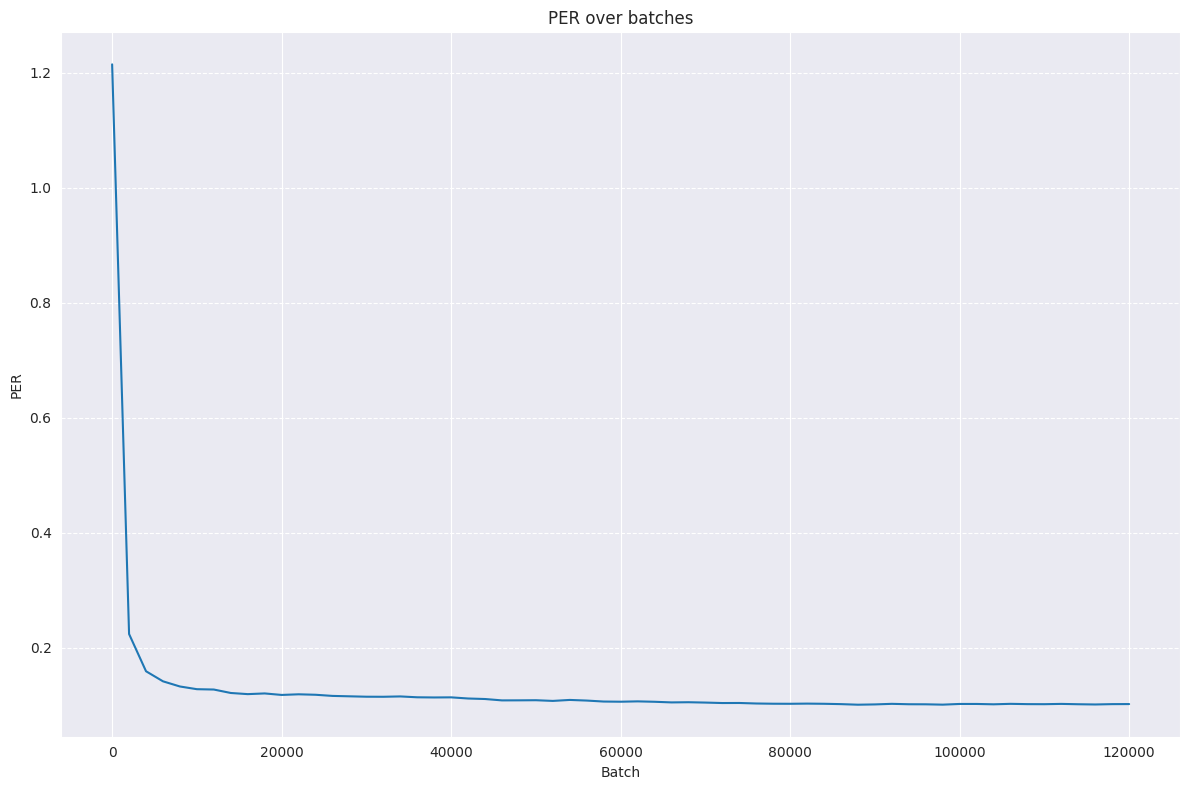

In [120]:
plt.figure(figsize=(12, 8))
plt.plot(df_val['batch'], df_val['per'])
plt.title('PER over batches')
plt.xlabel('Batch')
plt.ylabel('PER')
plt.grid(axis='y', linestyle='--')
# plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/PER_batches.png')
plt.show()

### AVG Loss over batches

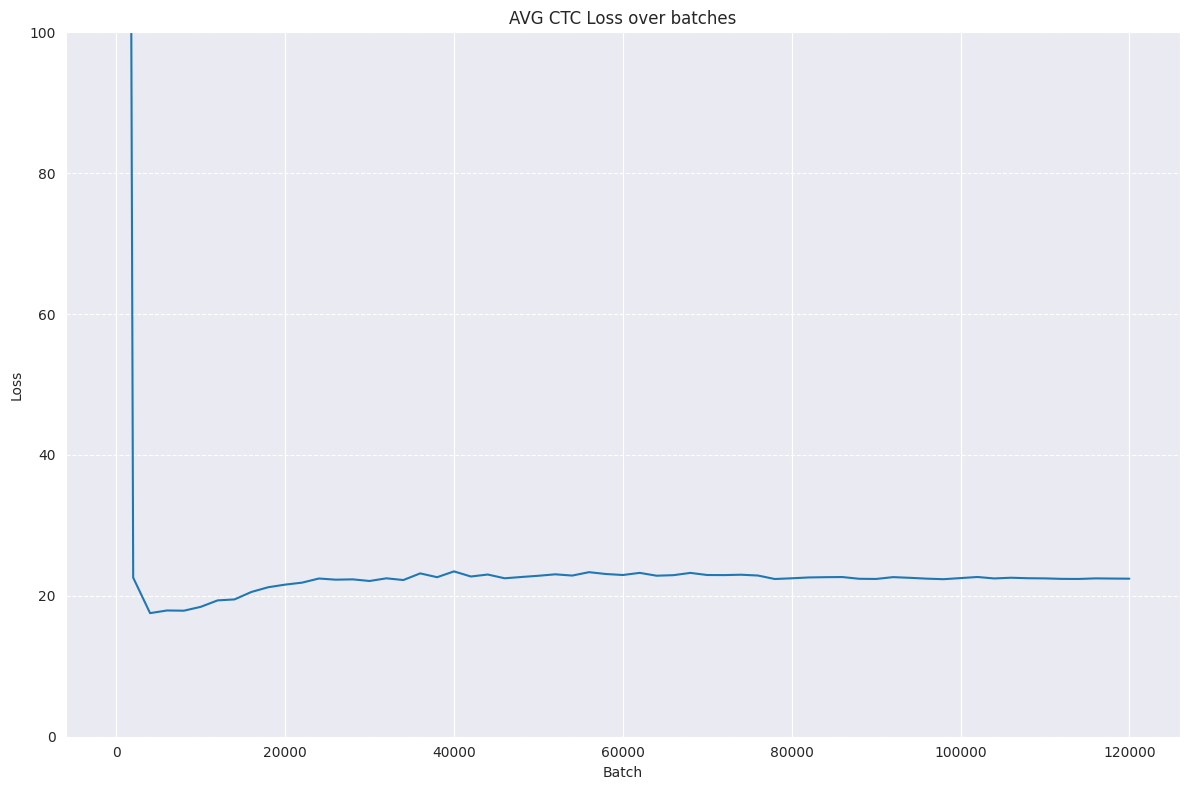

In [121]:
if greedy_or_beam:
    plt.figure(figsize=(12, 8))
    plt.plot(df_val['batch'], df_val['celoss'])
    plt.title('AVG Cross Entropy Loss over batches')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.grid(axis='y', linestyle='--')
    plt.ylim(0, 4.5)
else:
    plt.figure(figsize=(12, 8))
    plt.plot(df_val['batch'], df_val['ctcloss'])
    plt.title('AVG CTC Loss over batches')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.grid(axis='y', linestyle='--')
    plt.ylim(0, 100)

plt.tight_layout()
plt.savefig(f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/val_losses.png')
plt.show()

# For AdamER_RNN

In [122]:
# I want to extract the beta custom logs and plot it
rows = []

train_pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): Train batch (?P<batch>\d+): '
    r'loss: (?P<loss>[\d.]+) grad norm: (?P<grad_norm>[\d.]+) '
    r'time: (?P<time>[\d.]+)'
)

beta_pattern = re.compile(
    r'^(?P<timestamp>\S+ \S+): CUSTOM LOG: beta - (?P<beta>[\d.]+)$'
)

train_data = []
beta_data = []

with open(TRAINING_DATA_PATH) as f:
    for line in f:
        if 'Train batch' in line:
            match = train_pattern.match(line)
            if match and int(match['batch']) % 200 == 0:
                data = match.groupdict()
                data['batch'] = int(data['batch'])
                train_data.append(data)
        elif 'CUSTOM LOG: beta' in line:
            match = beta_pattern.match(line)
            if match:
                data = match.groupdict()
                data['beta'] = float(data['beta'])
                beta_data.append(data)

df_train = pd.DataFrame(train_data)
df_beta = pd.DataFrame(beta_data).drop(columns='timestamp')
df_final = pd.concat([df_train, df_beta], axis=1)

In [123]:
df_final

,timestamp,batch,loss,grad_norm,time,beta
0,"2025-11-02 20:20:36,749",0,755.12,299.78,3.962,0.100000
1,"2025-11-02 20:22:06,382",200,93.81,14.70,0.210,0.063301
2,"2025-11-02 20:22:55,442",400,74.17,39.42,0.259,0.035944
3,"2025-11-02 20:23:44,213",600,58.98,42.79,0.170,0.022890
4,"2025-11-02 20:24:33,582",800,52.48,60.08,0.256,0.016324
...,...,...,...,...,...,...
595,"2025-11-03 04:38:11,810",119000,0.00,0.10,0.249,0.000356
596,"2025-11-03 04:39:00,208",119200,0.02,2.14,0.227,0.000356
597,"2025-11-03 04:39:49,888",119400,0.01,0.30,0.216,0.000356
598,"2025-11-03 04:40:38,689",119600,0.01,1.13,0.323,0.000356


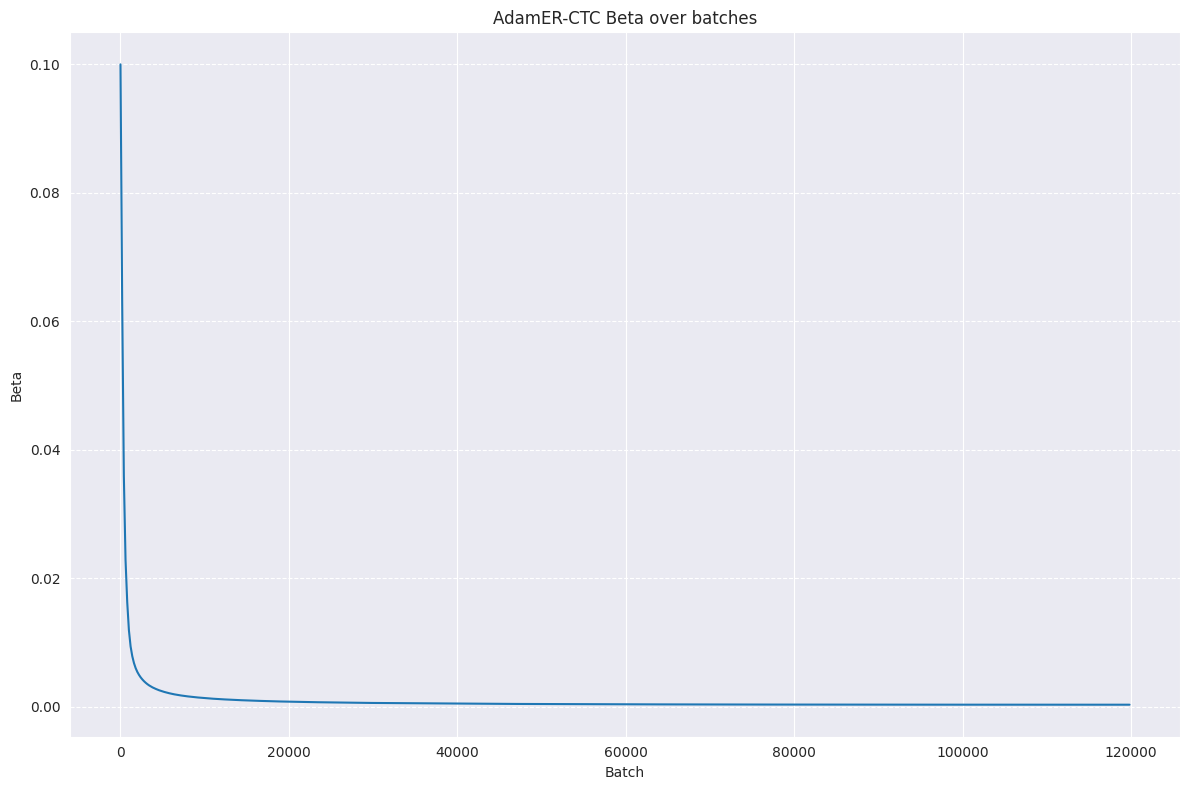

In [124]:
plt.figure(figsize=(12, 8))
plt.plot(df_final['batch'], df_final['beta'])
plt.title('AdamER-CTC Beta over batches')
plt.xlabel('Batch')
plt.ylabel('Beta')
plt.grid(axis='y', linestyle='--')
# plt.ylim(0, 0.1)

plt.tight_layout()
plt.savefig(f'./{MODEL_TYPE}/metrics/{MODEL_NAME}/AdamER-CTC_betas.png')
plt.show()